# Horizon-shift signal vs the foreground subspace

Antenna-position error changes the antenna temperature by
$\Delta T_\mathrm{ant}(\nu)$. This figure asks how much of that change lies
*outside* the subspace the foregrounds occupy: the $\Delta T_\mathrm{ant}$
spectra (top row, +1 m East/North/Up at 24 LSTs) are decomposed on the
foreground spectral modes -- the same SVD modes as `foreground_svd.npz`,
carried here as `Vh` -- and the bottom row plots the RMS of the component
orthogonal to the leading $N$ of them, for each simulated magnitude.

Grey is the 21 cm ensemble in the same orthogonal complement (5-95% of the
models, median dashed). It is a *yardstick* for how small a millikelvin number
has to be, not a signal being recovered here.

Grey is the 21 cm ensemble **in antenna temperature**: the models are
multiplied by the beam-weighted open-sky fraction $\eta = 1 - f_\mathrm{gnd}$
(0.36-0.55 across the band) before filtering, because $\Delta T_\mathrm{ant}$
and the modes are both uncorrected antenna temperature and an isotropic signal
reaches that observable attenuated. It is not the sky-referred global signal,
and it is 2.2 times smaller than one.

Data: `horizon_shift.npz`. Full derivation from the raw simulation output:
`mock_analysis/horizon_position/notebooks/horizon_shift.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

import eigsep_style as es

In [2]:
d = np.load("horizon_shift.npz", allow_pickle=True)
freqs = d["freqs_MHz"]
lst = d["lst_hr"]                 # LST [h] of each plotted spectrum
t21 = d["t21_pct"]                # (3, n_modes) retained 21 cm RMS [K], 5/50/95
dT_disp = d["dT_disp"]            # (3 axis, 3 mag, n_lst, n_freq) dT_ant [K]
mags = d["mags_m"]                # displacement magnitudes [m]
top_mag = float(d["top_mag_m"])   # the magnitude the spectra row draws
# Vh is the right singular basis of the nominal antenna-temperature waterfall:
# foreground_svd.npz t_sys minus the constant receiver temperature, uncentered.
_fs = np.load("foreground_svd.npz", allow_pickle=True)
_M = _fs["t_sys"] - float(_fs["t_receiver"])
_, s_fg, Vh = np.linalg.svd(_M, full_matrices=False)  # s_fg, Vh: (n_freq,), (n_freq, n_freq)
labels = [str(x) for x in d["labels"]]
N_ANCHOR = int(d["n_anchor"])     # the anchor depth, N_ANCHOR
n_hand = int(d["n_hand"])         # where the position error overtakes the
                                  # foreground floor, one mode inside it
pos_names = [str(x) for x in d["pos_names"]]
floor_own = d["floor_own"]        # floor at n_hand, each sky in its OWN basis
floor_nom = d["floor_nom"]        # ... and the same skies in the nominal basis
cv_penalty = float(d["cv_penalty"])
n_time = int(d["n_time"])
n_modes = np.arange(19)           # foreground modes filtered (x-axis)
print(dT_disp.shape, "at magnitudes", mags, "m; spectra row =", top_mag, "m")
print("LSTs", np.round(lst, 1))

(3, 3, 24, 201) at magnitudes [ 0.1  1.  10. ] m; spectra row = 1.0 m
LSTs [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23.]


In [5]:
def resid_curves(dT_axis, Vh, n_modes):
    """Per-row residual RMS over frequency [K] after filtering the leading N modes.

    ``dT_axis`` is (n_row, n_freq); rows are LSTs here and models for the 21 cm
    ensemble. Worst-case (per-row), not pooled -- the position systematic is
    quoted against its worst LST.
    """
    n_f = dT_axis.shape[1]
    coeff = dT_axis @ Vh.T
    return np.array([np.sqrt(np.sum(coeff[:, N:] ** 2, axis=1) / n_f)
                     for N in n_modes])                  # (n_modes, n_row)


def stays_below(curve, ref, n_modes):
    """Smallest N with curve < ref there and at every larger N on the axis.

    Not first-crossing: both fall with N and cross more than once, so a
    first-crossing rule reports an N the curve later climbs back above.
    """
    below = curve < ref
    return next((N for N in n_modes if below[N:].all()), None)


def make_figure(freqs, lst, t21, dT_disp, mags, top_mag, Vh, labels, n_modes, out_path):
    """The 2x3 horizon-shift figure. Returns the figure; also writes ``out_path``."""
    CMAP, norm = "twilight", Normalize(0, 24)
    C_21 = "0.40"                     # 21 cm band: grey and dashed, so it reads as
                                      # a benchmark in both rows without competing
                                      # with either row's colour encoding.
    D_COL = ["#6baed6", "#2171b5", "#08306b"]   # sequential: displacement is ordered
    cmap = plt.get_cmap(CMAP)
    n_f = freqs.size
    i_top = int(np.argmin(np.abs(mags - top_mag)))
    dT = dT_disp[:, i_top]                                  # (3, n_lst, n_freq)

    fig, axes = es.figure(
        cols=2, height_in=3.5232, nrows=2, ncols=3,
        gridspec_kw=dict(height_ratios=[1.6, 1.15]),
    )
    for col, lab in enumerate(labels):
        at, ab = axes[0, col], axes[1, col]
        for j in range(lst.size):                           # top: dT(nu) spectra
            at.plot(freqs, dT[col, j], color=cmap(norm(lst[j])), lw=0.7, alpha=0.9)
        at.axhline(0, color="0.5", lw=0.6, ls="--", zorder=0)
        at.set_title(lab, fontsize=8.5)
        at.set_xlabel("Frequency [MHz]", fontsize=8)
        at.grid(alpha=0.2); at.tick_params(labelsize=7)
        # Headroom for the magnitude tag. The three panels span very different
        # ranges and the curves reach the top of a different one in each, so the
        # tag needs space made for it rather than a corner that happens to be free.
        lo, hi = dT[col].min(), dT[col].max()
        at.set_ylim(lo - 0.05 * (hi - lo), hi + 0.30 * (hi - lo))
        at.text(0.97, 0.94, f"$+{top_mag:g}$ m", transform=at.transAxes,
                fontsize=6.5, color="0.35", ha="right", va="top")

        for k in range(mags.size):                          # bottom: all magnitudes
            rc = resid_curves(dT_disp[col, k], Vh, n_modes)  # (n_modes, n_lst)
            for j in range(lst.size):
                ab.plot(n_modes, rc[:, j], color=D_COL[k], lw=0.55, alpha=0.6)
        ab.fill_between(n_modes, t21[0], t21[2], color=C_21, alpha=0.25, lw=0, zorder=0)
        ab.plot(n_modes, t21[1], color=C_21, lw=1.4, ls="--", zorder=1)
        ab.set_yscale("log")
        ab.set_xlabel("Foreground modes filtered", fontsize=8)
        ab.grid(True, which="both", ls=":", lw=0.5, alpha=0.55)
        ab.set_xlim(0, n_modes[-1]); ab.set_ylim(3e-5, 30); ab.tick_params(labelsize=7)

    axes[0, 0].set_ylabel(r"$\Delta T_\mathrm{ant}$ [K]", fontsize=8)
    axes[1, 0].set_ylabel("Residual RMS [K]", fontsize=8)
    handles = [Line2D([], [], color=D_COL[k], lw=2, label=f"{mg:g} m")
               for k, mg in enumerate(mags)]
    handles.append(Line2D([], [], color=C_21, lw=1.4, ls="--", label="21-cm models"))
    # Upper right, not lower left: every curve descends with N, so the top-right
    # corner is the one reliably empty region in all three residual panels, while
    # the lower left still carries the 0.1 m tails.
    axes[1, 0].legend(handles=handles, fontsize=5.8, loc="upper right", ncol=2,
                      framealpha=0.9, handlelength=1.4, columnspacing=0.9,
                      borderpad=0.3, labelspacing=0.25)
    for col in (1, 2):
        axes[1, col].tick_params(labelleft=False)

    sm = ScalarMappable(norm=norm, cmap=CMAP)
    cb = fig.colorbar(sm, ax=axes[0, :], pad=0.012, fraction=0.03)
    cb.set_label("LST [h]", fontsize=8); cb.set_ticks(np.arange(0, 25, 6))
    cb.ax.tick_params(labelsize=7)

    es.save(fig, out_path)
    return fig

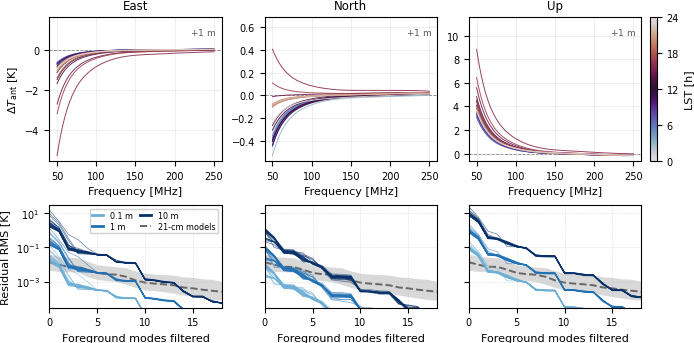

In [6]:
fig = make_figure(freqs, lst, t21, dT_disp, mags, top_mag, Vh,
                  labels, n_modes, "horizon_shift.pdf")